# Q7: How should current strategies be changed to achieve the set goals?

In the previous research question, we found that **Germany**, the **United Kingdom**, **France**, and **Ukraine** exhibit consistent downward trends and alignment with their defined targets, while the **United States** and **Japan**, although showing declining emissions, are not reducing them at a sufficient pace to meet their targets. **Russia** shows a stabilization of emissions without a significant downward trend, while **China** continues on an increasing emissions trajectory and does not reach a peak.

In this part of the analysis, the focus will be on understanding how existing strategies need to be adjusted in order for countries to increase the likelihood of achieving their climate targets. For this purpose, we will use the **XGBoost** algorithm to identify the key factors that have the greatest impact on emissions trends and the overall outcome relative to the defined targets. Additionally, we will train a **Random Forest** model to compare results and validate the robustness of the feature importance rankings.

In [80]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Loading the dataset

We use the same OWID dataset, selecting the following columns:
- `country`, `year`, `population`, `gdp`, `co2`, `coal_co2`, `gas_co2`, `oil_co2`, `land_use_change_co2`, `methane`, `nitrous_oxide`

We selected these columns because they are directly relevant to CO₂ emissions and reflect the main drivers of climate change without introducing redundancy or trivial correlations:

- `population` and `gdp` – represent demographic and economic activity, key factors influencing energy use and emissions.
- `coal_co2`, `gas_co2`, `oil_co2`, `cement_co2`, `flaring_co2` – primary sources of CO₂ emissions, critical for understanding contribution by sector.
- `land_use_change_co2` – captures emissions from deforestation and land-use changes.
- `methane` and `nitrous_oxide` – important greenhouse gases that may indirectly indicate industrial and agricultural emissions patterns.
- `year`, `country`, `iso_code` – provide context for temporal and spatial trends without leaking the target variable.

By limiting features to these columns, we avoid including derivatives or cumulative CO₂ values (which would trivially predict the target) and ensure that the model learns real, interpretable relationships between drivers and CO₂ emissions.

In [62]:
dataset_url="https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(dataset_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [63]:
relevant_columns = [
    'country', 'iso_code', 'year', 'co2', 
   'population', 'gdp',
    'coal_co2', 'gas_co2', 'oil_co2',
    'cement_co2', 'flaring_co2',
    'land_use_change_co2',
    'methane', 'nitrous_oxide'
]

goliaths = ["China", "United States", "Russia", "Japan", "Germany", "United Kingdom", "France", "Ukraine"]
goliaths_iso3 = ['CHN', 'USA', 'RUS', 'JPN', 'DEU', 'IND', 'GBR', 'SAU', 'IRN', 'FRA']

df_goliaths = df[df['iso_code'].isin(goliaths_iso3)][relevant_columns].copy()

In the previous analysis, we used data starting from 1970. Therefore, we will exclude all earlier values from the dataset.

In [64]:
df_goliaths = df_goliaths[df_goliaths['year'] >= 1970]

# Show first rows
df_goliaths.head()

,country,iso_code,year,co2,population,gdp,coal_co2,gas_co2,oil_co2,cement_co2,flaring_co2,land_use_change_co2,methane,nitrous_oxide
9879,China,CHN,1970,807.964,823308964.0,1.144004e+12,665.877,5.503,94.645,10.718,NaN,1336.049,586.169,133.666
9880,China,CHN,1971,909.210,844069870.0,1.216238e+12,736.435,7.174,120.091,13.113,0.791,882.614,605.290,137.753
9881,China,CHN,1972,968.636,863677810.0,1.233565e+12,770.736,9.281,138.328,14.693,1.022,1554.922,620.731,144.494
9882,China,CHN,1973,1008.269,882576945.0,1.334375e+12,783.755,11.468,158.820,15.417,1.264,1399.996,627.290,151.361
9883,China,CHN,1974,1028.063,900307580.0,1.367632e+12,776.116,14.440,182.573,15.289,1.634,1380.832,633.566,151.560


In [65]:
# Find if any country from goliaths_iso3 list is missing
df_iso3_codes = df_goliaths['iso_code'].unique()
missing = set(goliaths_iso3) - set(df_iso3_codes)
if not missing:
    print(f"SUCCESS: All {len(df_iso3_codes)} Goliaths are present in the dataset!")

SUCCESS: All 10 Goliaths are present in the dataset!


### Check for Missing Values

We inspect missing data to decide how to handle them. Target column co2 cannot have nulls. Other features can be filled or interpolated.

In [66]:
# Number of missing values per column
df_goliaths.isnull().sum()

country                 0
iso_code                0
year                    0
co2                     0
population              0
gdp                    20
coal_co2               10
gas_co2                 0
oil_co2                 0
cement_co2              0
flaring_co2            35
land_use_change_co2     0
methane                 0
nitrous_oxide           0
dtype: int64

In [67]:
# Percentage of missing values
(df_goliaths.isnull().mean() * 100).round(2)

country                0.00
iso_code               0.00
year                   0.00
co2                    0.00
population             0.00
gdp                    3.64
coal_co2               1.82
gas_co2                0.00
oil_co2                0.00
cement_co2             0.00
flaring_co2            6.36
land_use_change_co2    0.00
methane                0.00
nitrous_oxide          0.00
dtype: float64

There are very few missing values remaining. We will handle them using interpolation.

## Handle Missing Values

In [68]:
df_goliaths = df_goliaths.sort_values(by=['country', 'year'])

cols_to_interpolate = [
    'gdp', 'coal_co2', 'flaring_co2'
]

df_goliaths[cols_to_interpolate] = df_goliaths.groupby('country')[cols_to_interpolate] \
                                               .transform(lambda g: g.interpolate(method='linear', limit_direction='both'))

## Model Training with XGBoost

The next step is to train a machine learning model to understand the relationship between different factors and CO2 emissions.

In this section, we use the XGBoost regression model, which is well-suited for handling structured data and capturing complex relationships between variables.

In [69]:
def train_xgb_by_country(df, features, target='co2'):
    countries = df['country'].unique()
    results = {}

    for country in countries:
        df_country = df[df['country'] == country].sort_values('year')
        
        # target i features
        y = df_country[target]
        X = df_country[features]
        
        # model
        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        )
        
        model.fit(X, y)
        
        results[country] = pd.Series(
            model.feature_importances_, 
            index=features
        ).sort_values(ascending=False)

    return results

In [70]:
features_original = [
    'population', 'gdp',
    'coal_co2', 'gas_co2', 'oil_co2',
    'cement_co2', 'flaring_co2',
    'land_use_change_co2',
    'methane', 'nitrous_oxide'
]

results_original = train_xgb_by_country(df_goliaths, features_original)

In [71]:
importance_df = pd.DataFrame(results_original)
importance_table = importance_df.T
importance_table = importance_table.sort_values(by='coal_co2', ascending=False)

importance_table

,cement_co2,coal_co2,flaring_co2,gas_co2,gdp,land_use_change_co2,methane,nitrous_oxide,oil_co2,population
United States,0.009511,0.697474,0.000783,4.100947e-04,0.025873,0.051393,0.013265,0.006634,0.051577,0.143080
United Kingdom,0.000610,0.265138,0.000185,5.636995e-04,0.000024,0.000748,0.030909,0.005586,0.061435,0.634800
France,0.007354,0.077701,0.002545,6.769415e-03,0.001313,0.000426,0.003824,0.002219,0.047857,0.849992
Germany,0.000124,0.020533,0.020922,2.352599e-03,0.426413,0.016173,0.000413,0.004915,0.416854,0.091299
China,0.001227,0.010708,0.000003,1.838916e-07,0.043266,0.000446,0.000148,0.000010,0.006365,0.937826
Saudi Arabia,0.022394,0.007279,0.000247,1.804974e-02,0.018953,0.000003,0.003851,0.003684,0.090669,0.834869
Russia,0.000124,0.006699,0.000784,5.042896e-03,0.006105,0.000240,0.156492,0.001047,0.798525,0.024941
Japan,0.004049,0.002093,0.005911,3.164257e-03,0.002232,0.771166,0.000021,0.014423,0.052832,0.144109
Iran,0.008550,0.000046,0.002011,3.866873e-02,0.013938,0.000692,0.000045,0.000935,0.032083,0.903030
India,0.000000,0.000000,0.000000,1.762138e-08,0.173802,0.000000,0.000000,0.000312,0.000147,0.825740


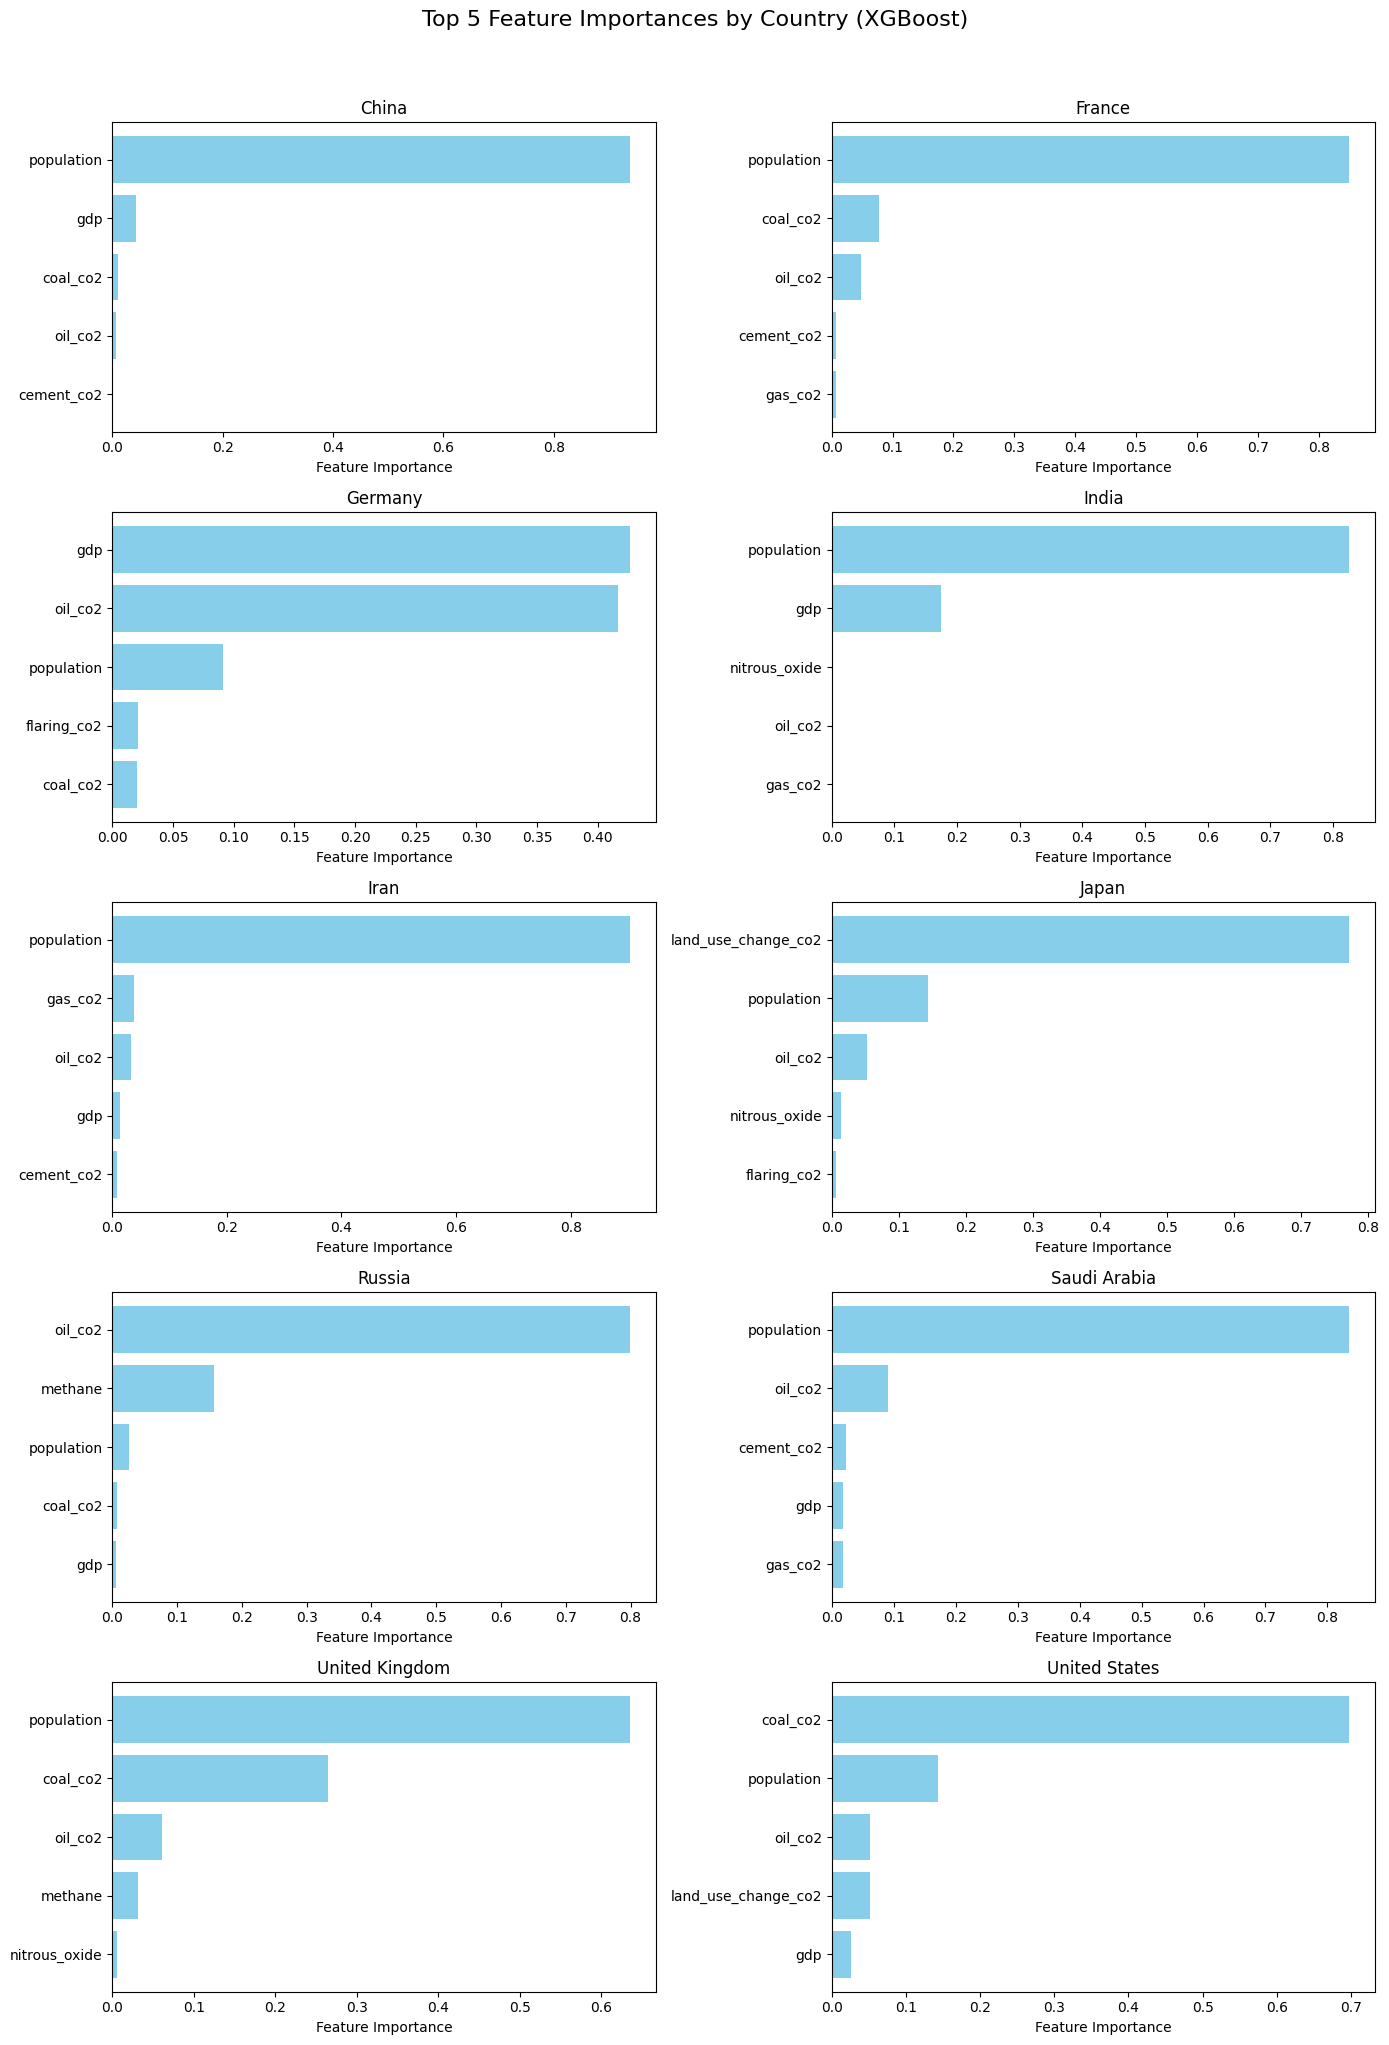

In [79]:
n_countries = len(countries)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("Top 5 Feature Importances by Country (XGBoost)", fontsize=16, y=1.02)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    # top five features
    top_features = results_original[country].head(5)
    ax.barh(top_features.index[::-1], top_features.values[::-1], color='skyblue')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Feature Importance")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Conclusion

- **United States** — **coal_co2 (0.697)**: Expected, as the US has long relied on coal for electricity and industry.
- **Russia** — **oil_co2 (0.799)** and **methane (0.156)**: Also expected, as Russia is a major oil and gas producer, including methane emissions from pipelines and industry.
- **China** — **population (0.938)**: China’s large population and urbanization make population the dominant factor.
- **India** — **population (0.826)** and **GDP (0.174)**: Expected, due to high population and growing economy.
- **Japan** — **land_use_change_co2 (0.771)**: Reflects limited resources and high urbanization.

- However, some **deviations** are notable:

    - **Saudi Arabia** — **population (0.835)**: Unexpected given the small population (~35 million). Realistically, gas_co2 and cement_co2 should dominate due to the large oil and gas industry and relatively low household consumption.
    - **France** — **population (0.850)**: Likely an effect of multicollinearity; nuclear power keeps CO2 emissions low, so the model attributes variability to population.
    - **Germany** — **GDP (0.426)** and **oil_co2 (0.417)**: GDP and oil_co2 often correlate, so the model may interpret GDP as a proxy for industrial activity rather than direct CO2 emissions.

Due to the observed deviations, population and GDP may be acting as proxy variables. To address this, an additional model will be tested without these features in order to better identify the true drivers of CO₂ emissions.

## Model Training with XGBoost (Industrial & Energy Factors Focus)

In [73]:
features_energy = [
    'coal_co2', 'gas_co2', 'oil_co2',
    'cement_co2', 'flaring_co2',
    'land_use_change_co2',
    'methane', 'nitrous_oxide'
]

results_energy = train_xgb_by_country(df_goliaths, features_energy)

In [74]:
importance_df = pd.DataFrame(results_energy)
importance_table = importance_df.T
importance_table = importance_table.sort_values(by='coal_co2', ascending=False)

importance_table

,cement_co2,coal_co2,flaring_co2,gas_co2,land_use_change_co2,methane,nitrous_oxide,oil_co2
India,0.036522,0.947731,0.000000,0.015222,0.000000,0.000000,0.000357,0.000168
China,0.001390,0.896186,0.000003,0.092723,0.000506,0.000168,0.000011,0.009012
France,0.007991,0.508287,0.008211,0.007156,0.000440,0.003201,0.001402,0.463311
United States,0.005293,0.336129,0.101633,0.004284,0.037681,0.005434,0.465876,0.043670
Saudi Arabia,0.013507,0.125241,0.000176,0.778725,0.000004,0.002760,0.003104,0.076484
Germany,0.000173,0.083672,0.016491,0.002455,0.019184,0.165099,0.004859,0.708067
United Kingdom,0.003507,0.063952,0.000111,0.000935,0.000382,0.523987,0.001726,0.405400
Japan,0.004896,0.016564,0.132808,0.013014,0.805475,0.000024,0.004780,0.022439
Iran,0.000382,0.005110,0.000476,0.982348,0.000286,0.000245,0.000168,0.010984
Russia,0.000299,0.004847,0.001222,0.038260,0.001293,0.156473,0.001191,0.796415


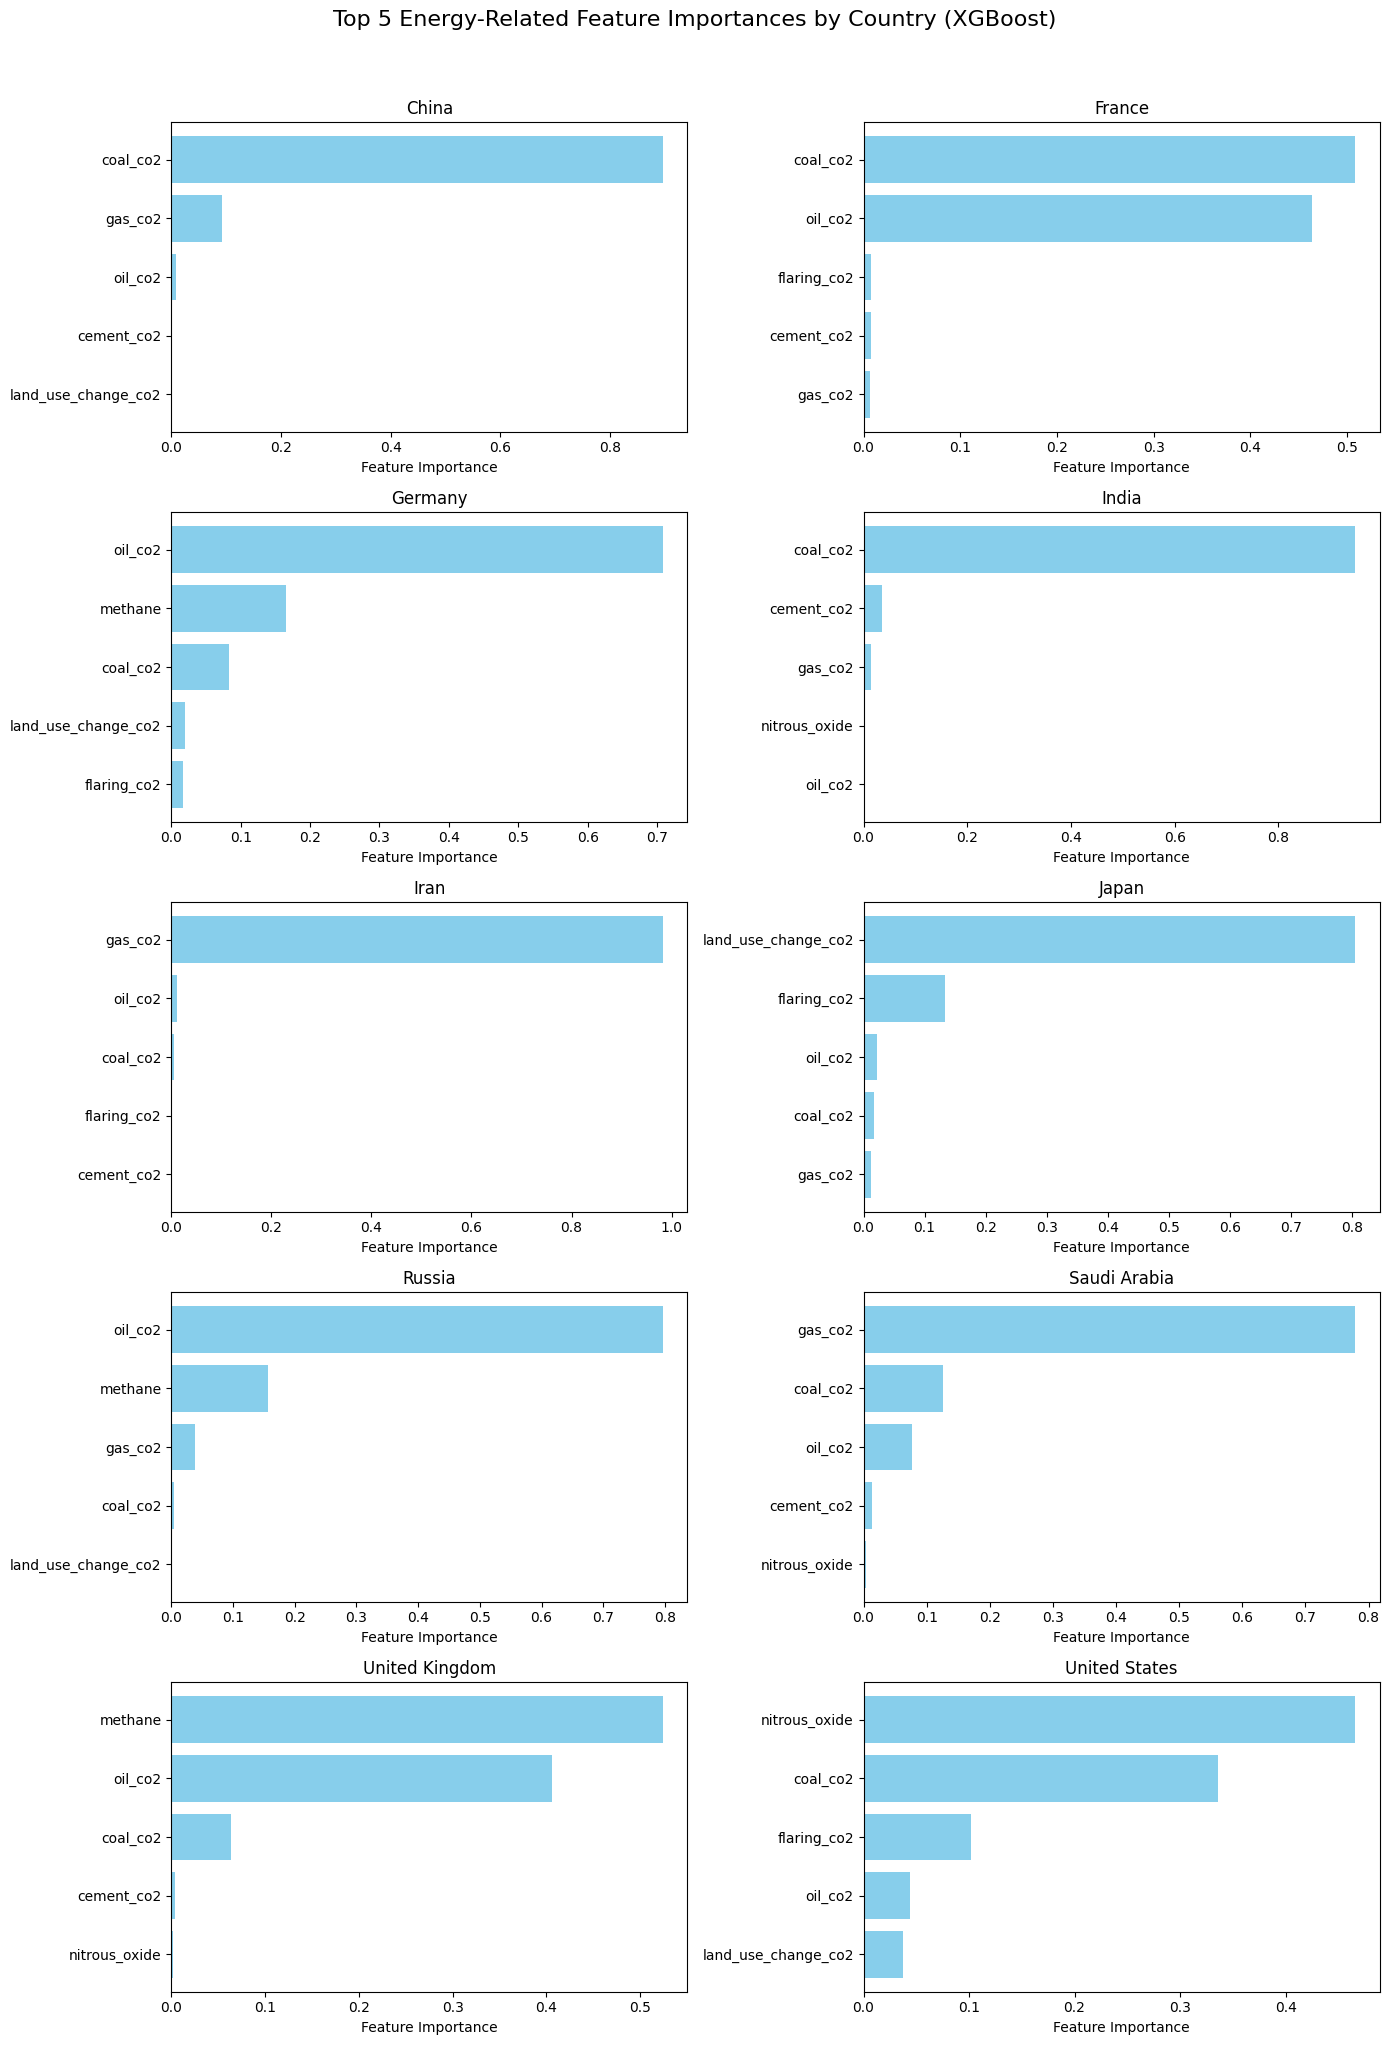

In [78]:
n_countries = len(countries)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("Top 5 Energy-Related Feature Importances by Country (XGBoost)", fontsize=16, y=1.02)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    # top five features
    top_features = results_energy[country].head(5)
    ax.barh(top_features.index[::-1], top_features.values[::-1], color='skyblue')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Feature Importance")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Results & Discussion
After removing population and GDP from the model, XGBoost identified energy-related variables as the dominant drivers of CO₂ emissions for most countries:
- **India**: `coal_CO₂` **(94.8%)** – expected, as the country heavily relies on coal for electricity.
- **China**: `coal_CO₂` **(89.6%)** and `gas_CO₂` **(9.3%)** – aligns with large industrial activity and urbanization.
- **Saudi Arabia**: `gas_CO₂` **(77.9%)** and `oil_CO₂` **(7.6%)** – realistic, due to large oil and gas industry and low household consumption.
- **Iran**: `gas_CO₂` **(98.2%)** – almost all emissions come from the gas industry.
- **Russia**: `oil_CO₂` **(79.6%)** and `methane` **(15.6%)** – expected, as Russia is a major fossil fuel producer and exporter.
- **Germany**: `oil_CO₂` **(70.8%)** and `methane` **(16.5%)** – reflects correlation between industrial and agricultural activity.
- **United Kingdom**: `methane` **(52.4%)** and `oil_CO₂` **(40.5%)** – dominant sources due to agriculture and industry.
- **Japan**: `land_use_change_CO₂` **(80.5%)** – possibly due to data specifics or indirect correlations, not actual high land-use emissions.
- **United States**: `nitrous_oxide` **(46.6%)** and `coal_CO₂` **(33.6%)** – reflects agricultural emissions and long-term reliance on coal.
- **France**: `coal_CO₂` **(50.8%)** and `oil_CO₂` **(46.3%)** – despite nuclear energy, industrial sources still contribute significantly.

## Model Training with Random Forest

In [84]:
def train_rf_by_country(df, features, target='co2'):
    countries = df['country'].unique()
    results = {}

    for country in countries:
        df_country = df[df['country'] == country].sort_values('year')
        y = df_country[target]
        X = df_country[features]
        
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=5,
            random_state=42
        )
        
        model.fit(X, y)
        results[country] = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    return results

First, we will consider both **demographic and industrial features** to understand which factors overall have the greatest impact on CO₂ emissions. Then, we will focus only on **industrial and energy-related features** to isolate the actual sources of emissions and assess their direct influence.

In [85]:
results_rf_original = train_rf_by_country(df_goliaths, features_original)

importance_df = pd.DataFrame(results_rf_original)
importance_table = importance_df.T
importance_table = importance_table.sort_values(by='coal_co2', ascending=False)

importance_table

,cement_co2,coal_co2,flaring_co2,gas_co2,gdp,land_use_change_co2,methane,nitrous_oxide,oil_co2,population
United States,0.020981,0.522254,0.062282,0.003859,0.095576,0.012172,0.095699,0.036718,0.067199,0.083262
United Kingdom,0.039474,0.164075,0.005338,0.007960,0.134371,0.006620,0.249475,0.014077,0.117107,0.261503
Germany,0.002911,0.150661,0.024833,0.019064,0.171884,0.021658,0.177858,0.170691,0.206300,0.054141
India,0.119525,0.145359,0.003115,0.126201,0.099061,0.006299,0.094068,0.156506,0.139116,0.110751
China,0.073663,0.113377,0.009300,0.125082,0.087604,0.137135,0.122848,0.100658,0.123386,0.106947
France,0.102499,0.103471,0.007972,0.082379,0.115374,0.064106,0.153067,0.010270,0.201350,0.159512
Japan,0.010377,0.026477,0.073330,0.022969,0.018205,0.518057,0.078012,0.016936,0.021463,0.214174
Russia,0.040558,0.024234,0.004322,0.022821,0.025876,0.003118,0.080372,0.055599,0.721603,0.021496
Saudi Arabia,0.095538,0.019708,0.013038,0.133001,0.115556,0.054701,0.169908,0.100454,0.174304,0.123793
Iran,0.163101,0.008489,0.007269,0.184275,0.237160,0.003281,0.001537,0.147157,0.039291,0.208440


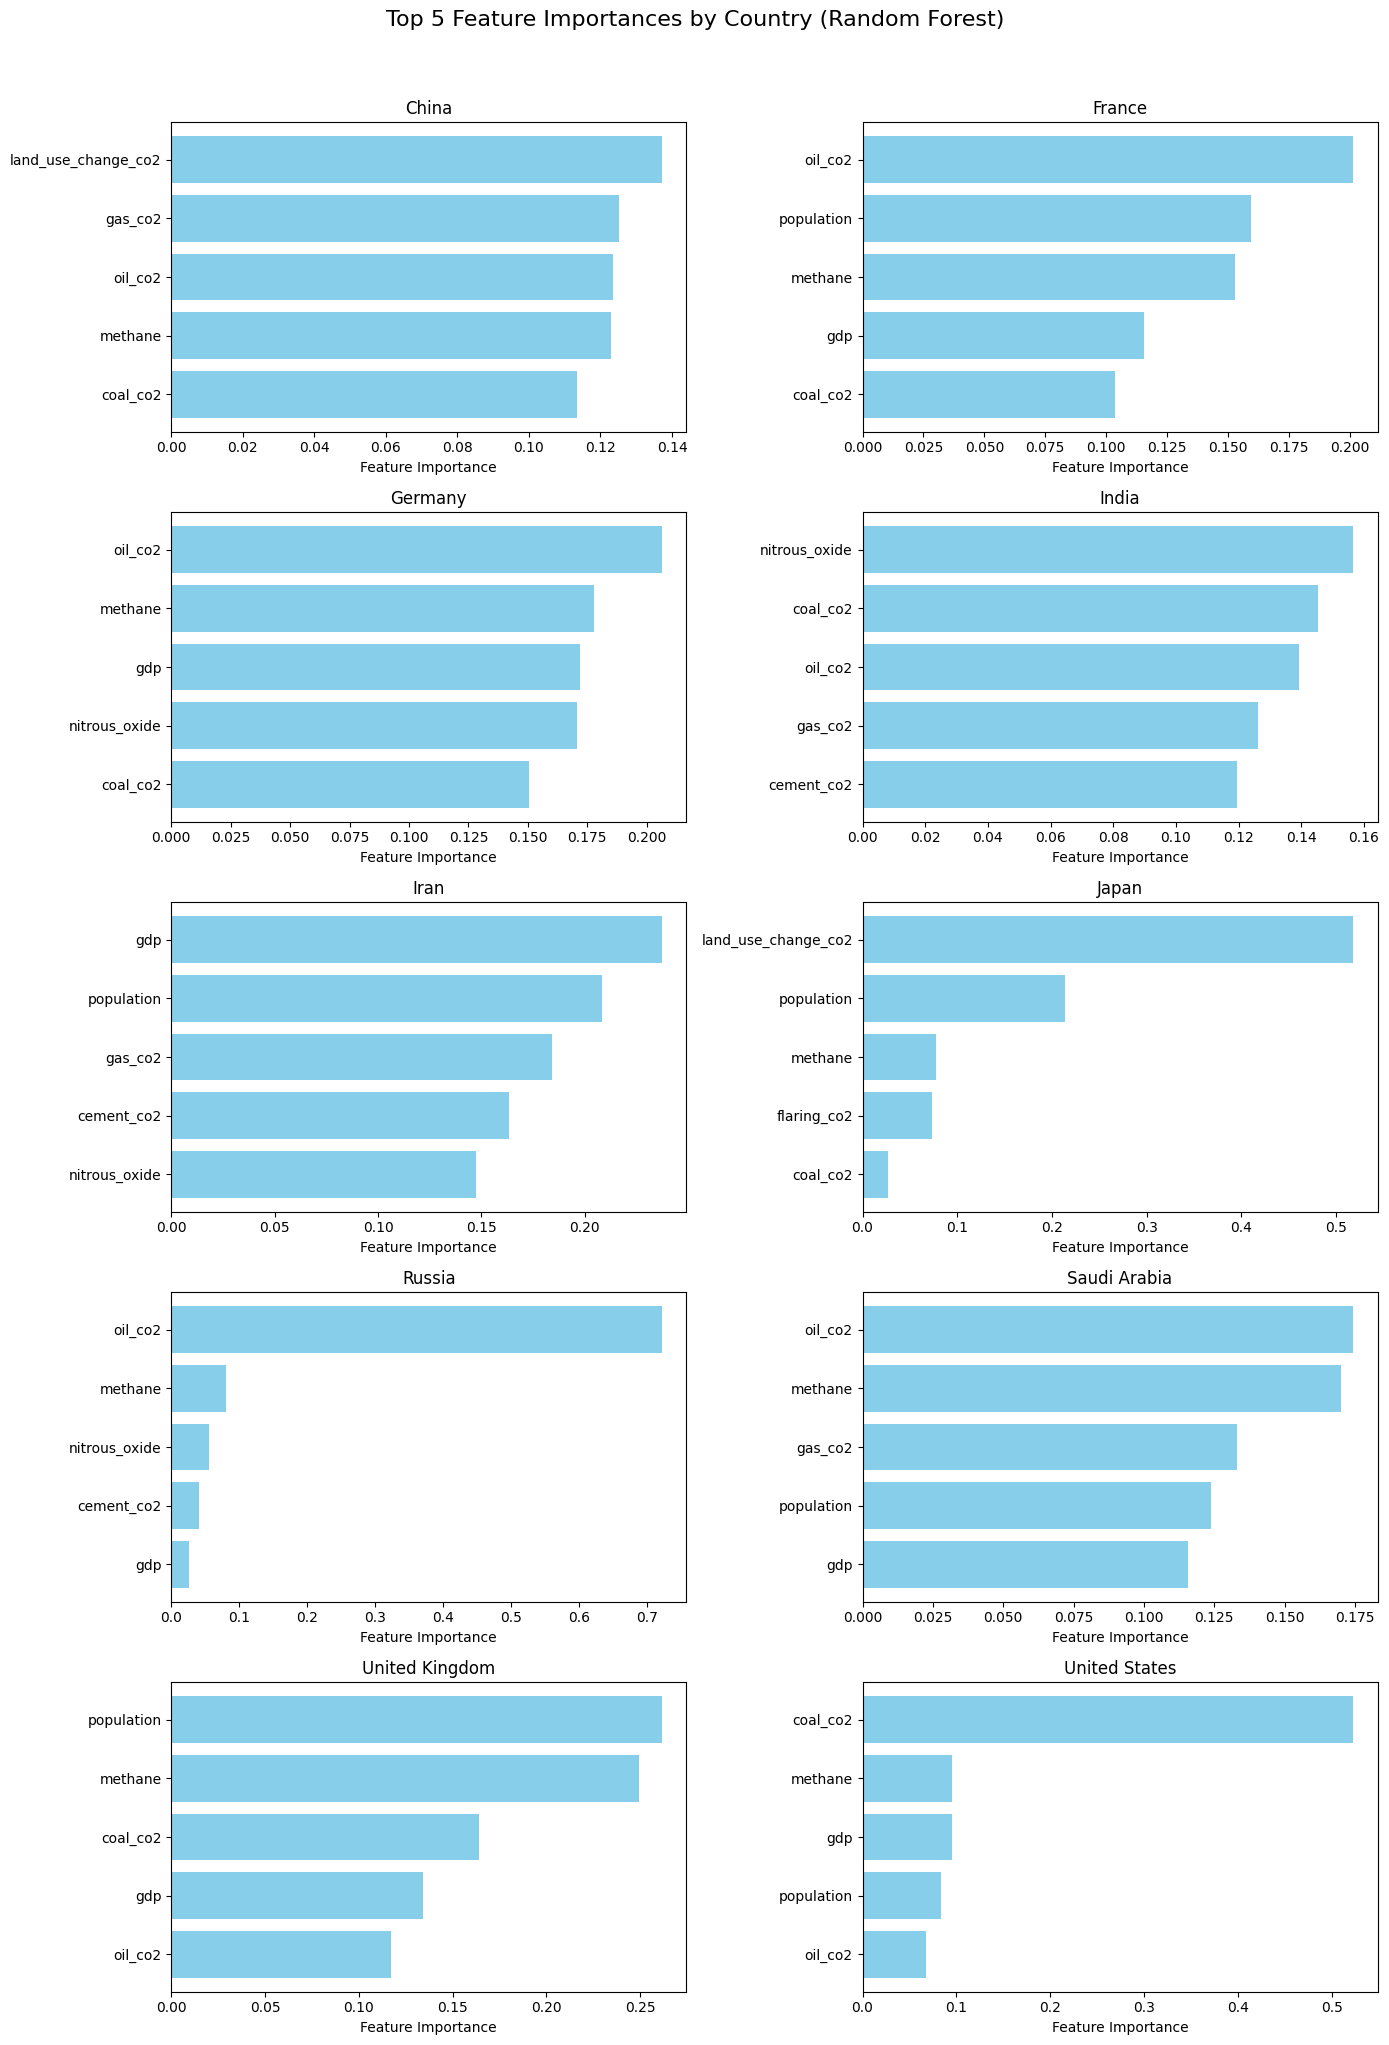

In [86]:
n_countries = len(countries)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("Top 5 Feature Importances by Country (Random Forest)", fontsize=16, y=1.02)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    # top five features
    top_features = results_rf_original[country].head(5)
    ax.barh(top_features.index[::-1], top_features.values[::-1], color='skyblue')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Feature Importance")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Conclusion
- **The Random Forest model confirms that energy sources (coal, gas, oil, cement, methane) dominate emissions in most countries** – especially in **India**, **China**, **Russia**, and **Saudi Arabia**.
- **Population and GDP have a secondary, but sometimes significant impact in countries with stable or clean energy structures** – examples: **France**, **United Kingdom**, **Japan**.
- In countries like **Russia**, **Saudi Arabia**, and **Iran**, **industrial factors are clearly the main drivers**, while **demographic factors contribute much less**.
- **There are correlations between GDP, population, and energy emissions**, which sometimes causes the model to “pick up” demographic features instead of direct CO₂ sources – observed in **France**, **UK**, and the **United States**.

## Model Training with Random Forest (Industrial & Energy Factors Focus)

In [87]:
results_rf_energy = train_rf_by_country(df_goliaths, features_energy)

importance_df = pd.DataFrame(results_rf_energy)
importance_table = importance_df.T
importance_table = importance_table.sort_values(by='coal_co2', ascending=False)

importance_table

,cement_co2,coal_co2,flaring_co2,gas_co2,land_use_change_co2,methane,nitrous_oxide,oil_co2
United States,0.023439,0.535342,0.131608,0.007341,0.015938,0.152884,0.069938,0.063511
United Kingdom,0.061115,0.276649,0.006272,0.015534,0.009779,0.428544,0.026423,0.175685
Germany,0.009061,0.191709,0.025797,0.015766,0.032555,0.265294,0.215540,0.244277
India,0.183060,0.162033,0.004115,0.150751,0.007737,0.108168,0.192109,0.192027
China,0.123137,0.157516,0.009186,0.152795,0.150369,0.134242,0.119644,0.153111
France,0.164143,0.136015,0.007171,0.086137,0.134432,0.193948,0.014129,0.264025
Japan,0.010992,0.044670,0.105567,0.052187,0.634181,0.109782,0.019659,0.022962
Saudi Arabia,0.118096,0.027563,0.015334,0.161984,0.063272,0.188680,0.145249,0.279822
Russia,0.030038,0.018142,0.005414,0.038483,0.005329,0.102929,0.057926,0.741739
Iran,0.280597,0.013441,0.010531,0.364994,0.004144,0.001722,0.268618,0.055954


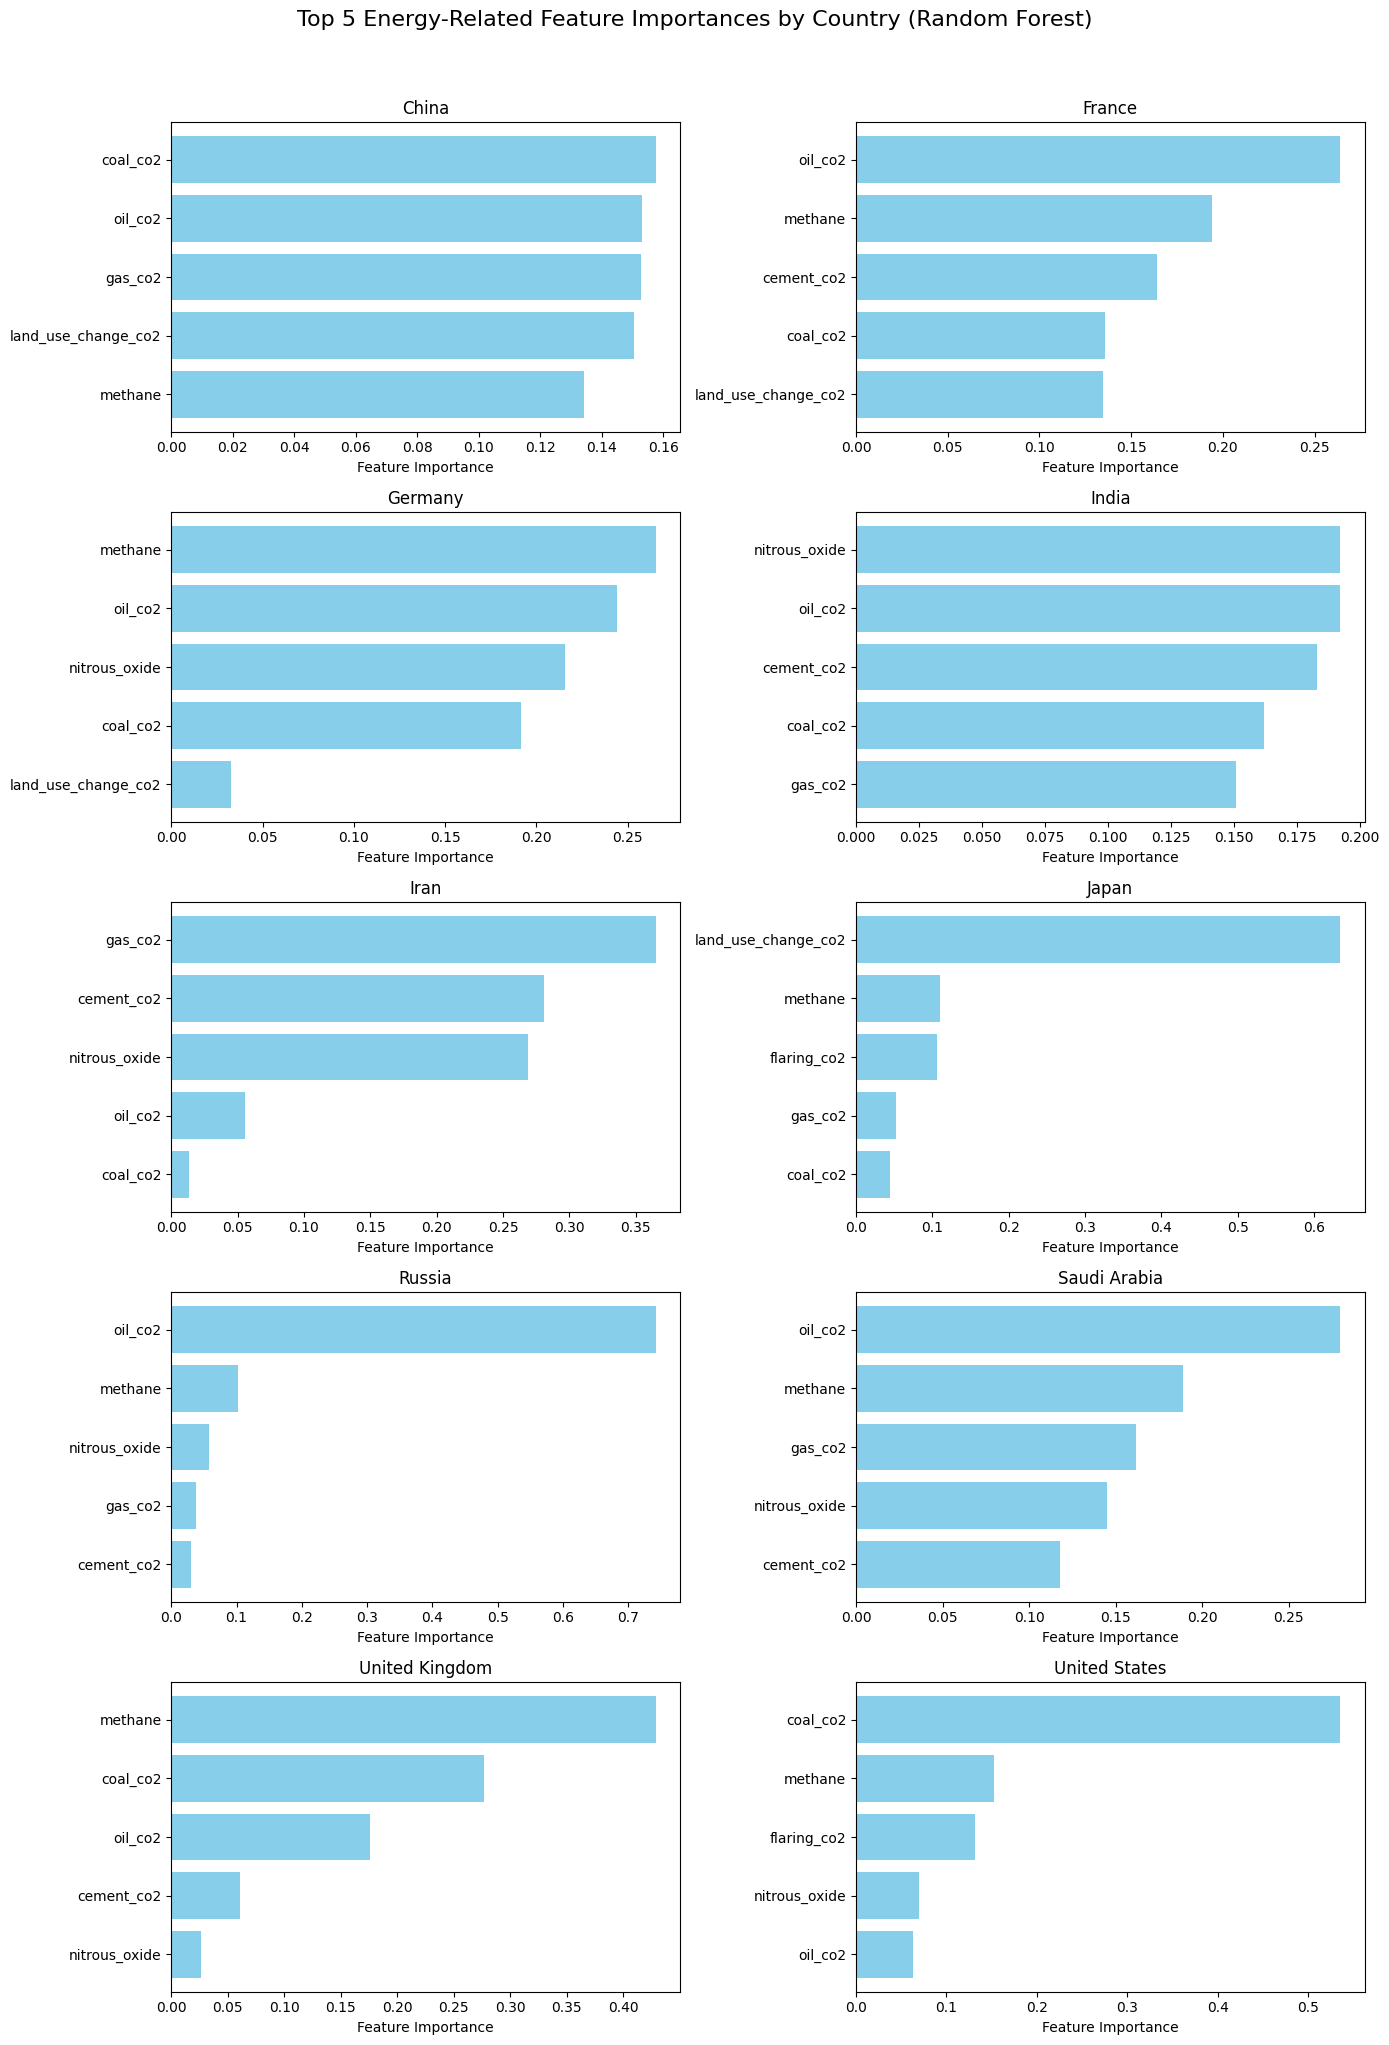

In [89]:
n_countries = len(countries)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
fig.suptitle("Top 5 Energy-Related Feature Importances by Country (Random Forest)", fontsize=16, y=1.02)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    # top five features
    top_features = results_rf_energy[country].head(5)
    ax.barh(top_features.index[::-1], top_features.values[::-1], color='skyblue')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Feature Importance")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Conclusion
By removing demographic factors, the model now better captures the actual energy and industrial sources of CO₂ for each country. The dominant sources are mainly coal, gas, oil, cement, and methane, while demographic effects no longer “distort” the results. This provides a clearer picture of which sectors should be targeted to reduce emissions.

## How to reduce CO₂ emissions by source
- **Population**: Provide clean energy for every new person.
- **GDP**: Grow the economy without increasing emissions – focus on green industry and recycling.
- **Coal (Coal CO₂)**: Replace coal power plants with solar, wind, or nuclear energy.
- **Gas (Gas CO₂)**: Move from gas heating to electrification, e.g., heat pumps.
- **Oil (Oil CO₂)**: Electrify transport and reduce fossil fuel use.
- **Cement (Cement CO₂)**: Use carbon capture technologies and low-carbon building materials.
- **Flaring (Flaring CO₂)**: Stop unnecessary gas flaring and improve oil well equipment.
- **Land use change (Land use CO₂)**: Stop deforestation and reforest degraded land.
- **Methane***: Close landfills and fix methane leaks in pipelines and industry.
- **Nitrous oxide**: Use fertilizers more efficiently and switch to organic alternatives.